In [ ]:
import re
from pathlib import Path

#import gensim
#import gensim.downloader as gensim_api
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import wordcloud
from sklearn import (
    decomposition,
    ensemble,
    feature_extraction,
    linear_model,
    metrics,
    model_selection,
    naive_bayes,
    pipeline,
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from tqdm.notebook import tqdm
from wordcloud import WordCloud
import nltk
from nltk.tokenize import word_tokenize
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from plotly.offline import iplot
import plotly.graph_objs as go
from sklearn.manifold import TSNE
import plotly.express as px
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/amazonreview/train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/amazonreview/test.csv")
dev_df = pd.read_csv("/content/drive/MyDrive/amazonreview/validation.csv")

In [ ]:
# Print the number of examples in the training set
# Training set has 1.2 million examples (95.2% of the total data)
print(f"Training Examples: {train_df.shape[0]}")

# Print the number of examples in the testing set
# Testing set has 30,000 examples (2.4% of the total data)
print(f"Testing Examples: {test_df.shape[0]}")

# Print the number of examples in the development (validation) set
# Development set has 30,000 examples (2.4% of the total data)
print(f"Development Examples: {dev_df.shape[0]}")

# Calculate the total number of examples across all datasets
total_examples = train_df.shape[0] + test_df.shape[0] + dev_df.shape[0]
print(f"Total Examples: {total_examples}")  # Should equal 1.26 million in this case

# Calculate the percentage of examples in the test set
test_set_percentage = test_df.shape[0] / total_examples * 100

# Calculate the percentage of examples in the development set
dev_set_percentage = dev_df.shape[0] / total_examples * 100

# Calculate the percentage of examples in the training set
train_set_percentage = train_df.shape[0] / total_examples * 100

# Print the calculated percentages for each dataset
# Should confirm the split as approximately 95.2% training, 2.4% testing, and 2.4% development
print(f"Test Set Percentage: {test_set_percentage:.1f}%")
print(f"Development Set Percentage: {dev_set_percentage:.1f}%")
print(f"Training Set Percentage: {train_set_percentage:.1f}%")

Training Examples: 1200000
Testing Examples: 30000
Development Examples: 30000
Total Examples: 1260000
Test Set Percentage: 2.4%
Development Set Percentage: 2.4%
Training Set Percentage: 95.2%


In [ ]:
train_df.head()

,Unnamed: 0,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category
0,0,de_0203609,product_de_0865382,reviewer_de_0267719,1,Armband ist leider nach 1 Jahr kaputt gegangen,Leider nach 1 Jahr kaputt,de,sports
1,1,de_0559494,product_de_0678997,reviewer_de_0783625,1,In der Lieferung war nur Ein Akku!,EINS statt ZWEI Akkus!!!,de,home_improvement
2,2,de_0238777,product_de_0372235,reviewer_de_0911426,1,"Ein Stern, weil gar keine geht nicht. Es hande...",Achtung Abzocke,de,drugstore
3,3,de_0477884,product_de_0719501,reviewer_de_0836478,1,"Dachte, das wären einfach etwas festere Binden...",Zu viel des Guten,de,drugstore
4,4,de_0270868,product_de_0022613,reviewer_de_0736276,1,Meine Kinder haben kaum damit gespielt und nac...,Qualität sehr schlecht,de,toy


In [ ]:
# Define the target languages to include in the filtered datasets
target_languages = ['en', 'es', 'fr', 'de']  # English, Spanish, French, German

# Filter the training dataset to include only examples in the target languages
# Result: 800,000 examples remain after filtering
train_df = train_df[train_df['language'].isin(target_languages)]

# Filter the development (validation) dataset to include only examples in the target languages
# Result: 20,000 examples remain after filtering
dev_df = dev_df[dev_df['language'].isin(target_languages)]

# Filter the testing dataset to include only examples in the target languages
# Result: 20,000 examples remain after filtering
test_df = test_df[test_df['language'].isin(target_languages)]

In [ ]:
train_df = train_df[['review_body', 'stars']]
test_df = test_df[['review_body', 'stars']]
dev_df = dev_df[['review_body', 'stars']]

In [ ]:
def convert_to_polarity(stars):
    '''
    Converts star ratings into sentiment polarity categories.
    Input:
      - stars: An integer representing the star rating (1 to 5).
    Output:
      - 0 for negative sentiment (1 or 2 stars)
      - 1 for neutral sentiment (3 stars)
      - 2 for positive sentiment (4 or 5 stars)
    '''
    if stars in [1, 2]:
        return 0  # Negative sentiment
    elif stars == 3:
        return 1  # Neutral sentiment
    elif stars in [4, 5]:
        return 2  # Positive sentiment

# Apply the `convert_to_polarity` function to the 'stars' column in each dataset
# This creates a new 'polarity' column representing sentiment
train_df['polarity'] = train_df['stars'].apply(convert_to_polarity)  # Polarity for training data
test_df['polarity'] = test_df['stars'].apply(convert_to_polarity)   # Polarity for test data
dev_df['polarity'] = dev_df['stars'].apply(convert_to_polarity)     # Polarity for validation data

In [ ]:
train_df.head()

,review_body,stars,polarity
0,Armband ist leider nach 1 Jahr kaputt gegangen,1,0
1,In der Lieferung war nur Ein Akku!,1,0
2,"Ein Stern, weil gar keine geht nicht. Es hande...",1,0
3,"Dachte, das wären einfach etwas festere Binden...",1,0
4,Meine Kinder haben kaum damit gespielt und nac...,1,0


In [ ]:
# Since the datasets are incredibly large, and due to processing and memory limitations,
# I will only use a subset of the data. The subset will still preserve the proportion of
# samples with respect to the star ratings to maintain dataset balance.

# Define the total size of the new subset
new_total_size = 84000  # Total number of samples to use across train, dev, and test subsets

# Define the proportions for each subset (70% training, 20% development, 10% testing)
train_size = int(new_total_size * 0.70)  # 70% of the total size
dev_size = int(new_total_size * 0.20)    # 20% of the total size
test_size = int(new_total_size * 0.10)   # 10% of the total size

# Function to create a stratified sample
def stratified_sample(df, target_col, sample_size):
    """
    Create a stratified sample from the dataset.
    Ensures the proportion of each category in the target column (e.g., star ratings)
    is preserved in the sample.

    Parameters:
    - df (DataFrame): The input dataset to sample from
    - target_col (str): The column name representing categories (e.g., 'stars')
    - sample_size (int): The total number of samples to extract from the dataset

    Returns:
    - DataFrame: A stratified sample of the dataset with preserved proportions
    """
    # Group by the target column and sample from each group based on its proportion
    stratified_sample = df.groupby(target_col, group_keys=False).apply(
        lambda x: x.sample(n=min(len(x), int(sample_size * len(x) / len(df))), random_state=42)
    )
    return stratified_sample

# Perform stratified sampling for training, development, and test subsets
train_subset = stratified_sample(train_df, target_col='stars', sample_size=train_size)
dev_subset = stratified_sample(dev_df, target_col='stars', sample_size=dev_size)
test_subset = stratified_sample(test_df, target_col='stars', sample_size=test_size)

# Verify that the star rating proportions are preserved in each subset
print("Train Subset Distribution:")
print(train_subset['stars'].value_counts(normalize=True))  # Prints proportions of star ratings in training data

print("Dev Subset Distribution:")
print(dev_subset['stars'].value_counts(normalize=True))    # Prints proportions of star ratings in development data

print("Test Subset Distribution:")
print(test_subset['stars'].value_counts(normalize=True))   # Prints proportions of star ratings in testing data

Train Subset Distribution:
stars
1    0.2
2    0.2
3    0.2
4    0.2
5    0.2
Name: proportion, dtype: float64
Dev Subset Distribution:
stars
1    0.2
2    0.2
3    0.2
4    0.2
5    0.2
Name: proportion, dtype: float64
Test Subset Distribution:
stars
1    0.2
2    0.2
3    0.2
4    0.2
5    0.2
Name: proportion, dtype: float64


/tmp/ipykernel_7049/1376775785.py:29: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_7049/1376775785.py:29: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_7049/1376775785.py:29: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Eithe

/tmp/ipykernel_7049/1529809960.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




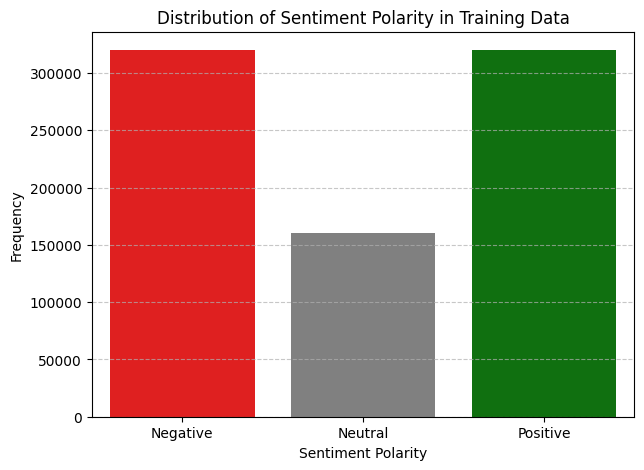

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count occurrences of each polarity in the dataset
polarity_counts = train_df['polarity'].value_counts().sort_index()

# Define sentiment labels
sentiment_labels = {0: "Negative", 1: "Neutral", 2: "Positive"}

# Plot the sentiment distribution
plt.figure(figsize=(7, 5))
sns.barplot(x=polarity_counts.index, y=polarity_counts.values, palette=['red', 'gray', 'green'])

# Labeling the chart
plt.xticks(ticks=polarity_counts.index, labels=[sentiment_labels[i] for i in polarity_counts.index])
plt.xlabel("Sentiment Polarity")
plt.ylabel("Frequency")
plt.title("Distribution of Sentiment Polarity in Training Data")
plt.grid(axis='y', linestyle="--", alpha=0.7)

# Show the plot
plt.show()


In [ ]:
train_df.head()

,review_body,stars,polarity
0,Armband ist leider nach 1 Jahr kaputt gegangen,1,0
1,In der Lieferung war nur Ein Akku!,1,0
2,"Ein Stern, weil gar keine geht nicht. Es hande...",1,0
3,"Dachte, das wären einfach etwas festere Binden...",1,0
4,Meine Kinder haben kaum damit gespielt und nac...,1,0


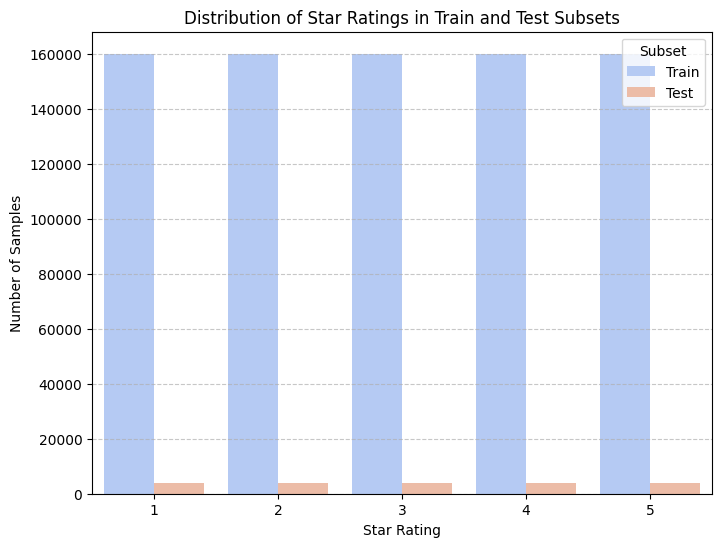

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import model_selection

# Split the data into train and test
#train_df, test_df = model_selection.train_test_split(df, test_size=0.2, random_state=1)

# Define subsets for visualization
subset_labels = ['Train', 'Test']
subset_dfs = [train_df, test_df]

# Create a dataframe for visualization
subset_data = []
for label, df in zip(subset_labels, subset_dfs):
    star_counts = df['stars'].value_counts().sort_index()
    for star, count in star_counts.items():
        subset_data.append({'Subset': label, 'Star Rating': star, 'Count': count})

subset_df = pd.DataFrame(subset_data)

# Plot the distribution of star ratings across subsets
plt.figure(figsize=(8, 6))
sns.barplot(data=subset_df, x="Star Rating", y="Count", hue="Subset", palette="coolwarm")

# Labeling the chart
plt.xlabel("Star Rating")
plt.ylabel("Number of Samples")
plt.title("Distribution of Star Ratings in Train and Test Subsets")
plt.legend(title="Subset")
plt.grid(axis='y', linestyle="--", alpha=0.7)

# Show the plot
plt.show()


In [ ]:
# Define a preprocessing function to format the data for model input
def preprocess_function(example):
    """
    Preprocesses the input examples to create a text-label mapping.

    Parameters:
    - example (dict): A dictionary containing 'review_body' (text) and 'polarity' (label).

    Returns:
    - dict: A dictionary with the processed text and label ready for training.
      Keys:
        - "text": The review text (from 'review_body')
        - "label": The polarity label (from 'polarity')
    """
    return {
        "text": example["review_body"],  # Map the review text
        "label": example["polarity"]    # Map the polarity label
    }

In [ ]:
from datasets import Dataset

# Import pandas for data manipulation and analysis
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Import Trainer and TrainingArguments for fine-tuning and training models
from transformers import Trainer, TrainingArguments

# Import accuracy_score and precision_recall_fscore_support for custom evaluation metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import EarlyStoppingCallback

#Import warnings to silence warnings that are not causing issues with the model output
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch.nn.parallel")

In [ ]:
# Convert the stratified subsets into Hugging Face Dataset objects
# Include only the 'review_body' (text) and 'polarity' (label) columns
train_set = Dataset.from_pandas(train_subset[['review_body', 'polarity']])  # Training dataset
test_set = Dataset.from_pandas(test_subset[['review_body', 'polarity']])    # Testing dataset
dev_set = Dataset.from_pandas(dev_subset[['review_body', 'polarity']])      # Development (validation) dataset

# Preprocess the datasets by applying the preprocessing function
# The `map` function applies the `preprocess_function` to all examples in the dataset
train_set = train_set.map(preprocess_function, batched=True)  # Preprocess training dataset
test_set = test_set.map(preprocess_function, batched=True)    # Preprocess testing dataset
dev_set = dev_set.map(preprocess_function, batched=True)      # Preprocess development dataset

Map:   0%|          | 0/58795 [00:00<?, ? examples/s]

Map:   0%|          | 0/8400 [00:00<?, ? examples/s]

Map:   0%|          | 0/16800 [00:00<?, ? examples/s]

In [ ]:
# Using a multilingual BERT model fine-tuned for sentiment classification
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"

# Load the tokenizer associated with the specified model
# This tokenizer is used to tokenize the text inputs into the format required by the model
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
def tokenize_function(examples):
    """
    Tokenizes the input examples for the model.

    Parameters:
    - examples (dict): A dictionary containing the "text" field to be tokenized.

    Returns:
    - dict: A dictionary with tokenized input features, including:
      - input_ids: Tokenized numerical representation of the text
      - attention_mask: Indicates which tokens are padding
    """
    # Tokenize the text with the following parameters:
    # - padding="max_length": Ensures all sequences are padded to the same length (128 tokens here)
    # - truncation=True: Truncates text that exceeds the maximum length
    # - max_length=128: Specifies the maximum token length for each input
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

In [ ]:
tokenized_train = train_set.map(tokenize_function, batched=True)

# Apply the tokenize function to the test dataset
tokenized_test = test_set.map(tokenize_function, batched=True)

# Apply the tokenize function to the development (validation) dataset
tokenized_dev = dev_set.map(tokenize_function, batched=True)

Map:   0%|          | 0/58795 [00:00<?, ? examples/s]

Map:   0%|          | 0/8400 [00:00<?, ? examples/s]

Map:   0%|          | 0/16800 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    ignore_mismatched_sizes=True
)

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nlptown/bert-base-multilingual-uncased-sentiment
Key               | Status   |                                                                                     
------------------+----------+-------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([5, 768]) vs model:torch.Size([3, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([5]) vs model:torch.Size([3])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
import transformers
print(transformers.__version__)

5.0.0


In [ ]:
pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 43.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",            # ✅ Changed from evaluation_strategy
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True
)


In [ ]:
def compute_metrics(eval_pred):
    """
    Computes evaluation metrics for the model's predictions.

    Args:
        eval_pred (tuple): A tuple containing:
            - logits (ndarray): The predicted raw scores (logits) from the model.
            - labels (ndarray): The true labels for the evaluation dataset.

    Returns:
        dict: A dictionary containing accuracy, F1 score, precision, and recall.
          """
    # Unpack the logits and true labels from the evaluation predictions
    logits, labels = eval_pred

    # Convert logits to predicted class indices by selecting the maximum score
    predictions = np.argmax(logits, axis=-1)

    # Compute precision, recall, and F1-score using scikit-learn
    # 'average="weighted"' ensures metrics account for label imbalance
    # 'zero_division=1' avoids division errors when precision/recall are undefined
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=1
    )
     # Compute accuracy as the proportion of correct predictions
    acc = accuracy_score(labels, predictions)

    # Return a dictionary containing all calculated metrics
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

In [ ]:
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_dev,
    processing_class=tokenizer,       # ✅ Changed from tokenizer
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=1)
    ],
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning:

'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.



Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss


In [ ]:
#Evaluate accuracy of training and validation sets

train_results = trainer.evaluate(tokenized_train)
print(f"Train Accuracy: {train_results['eval_accuracy']:.4f}")  # Print train accuracy
print(f"Train F1 Score: {train_results['eval_f1']:.4f}")     # Print train F1 score

dev_results = trainer.evaluate(tokenized_dev)
print(f"Validation Accuracy: {dev_results['eval_accuracy']:.4f}")  # Print validation accuracy
print(f"Validation F1 Score: {dev_results['eval_f1']:.4f}")     # Print validation F1 score

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

# ============================================================
# Get predictions from the model for all datasets
# ============================================================

def get_predictions(trainer, dataset):
    """
    Get predictions, labels, and probabilities from the trainer.
    """
    # Get predictions (includes logits)
    outputs = trainer.predict(dataset)
    logits = outputs.predictions
    labels = outputs.label_ids

    # Convert logits to predicted class indices
    predictions = np.argmax(logits, axis=-1)

    # Get probabilities using softmax
    probs = np.exp(logits) / np.exp(logits).sum(axis=-1, keepdims=True)

    return predictions, labels, probs

# Get predictions for all datasets
train_preds, train_labels, train_probs = get_predictions(trainer, tokenized_train)
dev_preds, dev_labels, dev_probs = get_predictions(trainer, tokenized_dev)
test_preds, test_labels, test_probs = get_predictions(trainer, tokenized_test)

# Determine number of classes
n_classes = len(np.unique(train_labels))
class_names = [f"Class {i}" for i in range(n_classes)]  # Replace with actual class names if available

In [ ]:
# ============================================================
# Classification Report
# ============================================================

print("=" * 60)
print("CLASSIFICATION REPORTS")
print("=" * 60)

print("\n📊 TRAINING SET CLASSIFICATION REPORT:")
print("-" * 50)
print(classification_report(train_labels, train_preds, target_names=class_names))

print("\n📊 VALIDATION SET CLASSIFICATION REPORT:")
print("-" * 50)
print(classification_report(dev_labels, dev_preds, target_names=class_names))

print("\n📊 TEST SET CLASSIFICATION REPORT:")
print("-" * 50)
print(classification_report(test_labels, test_preds, target_names=class_names))

In [ ]:
# ============================================================
# Confusion Matrix Visualization
# ============================================================

def plot_confusion_matrix(y_true, y_pred, class_names, title, cmap='Blues'):
    """
    Plot a confusion matrix with annotations.
    """
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=class_names,
                yticklabels=class_names,
                cbar_kws={'label': 'Count'})

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

    return cm

# Plot confusion matrices for all datasets
print("\n" + "=" * 60)
print("CONFUSION MATRICES")
print("=" * 60)

cm_train = plot_confusion_matrix(train_labels, train_preds, class_names,
                                  "Training Set Confusion Matrix", cmap='Blues')

cm_dev = plot_confusion_matrix(dev_labels, dev_preds, class_names,
                                "Validation Set Confusion Matrix", cmap='Oranges')

cm_test = plot_confusion_matrix(test_labels, test_preds, class_names,
                                 "Test Set Confusion Matrix", cmap='Greens')

In [ ]:
# ============================================================
# ROC AUC Curve
# ============================================================

def plot_roc_curve(y_true, y_probs, n_classes, class_names, title):
    """
    Plot ROC curves for multi-class classification.

    For binary classification: plots single ROC curve
    For multi-class: plots one-vs-rest ROC curves for each class
    """
    plt.figure(figsize=(10, 8))

    if n_classes == 2:
        # Binary classification
        fpr, tpr, _ = roc_curve(y_true, y_probs[:, 1])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
                 label='Random Classifier')

        # Calculate and display AUC score
        auc_score = roc_auc_score(y_true, y_probs[:, 1])
        print(f"AUC Score: {auc_score:.4f}")

    else:
        # Multi-class classification (One-vs-Rest)
        # Binarize the labels for one-vs-rest approach
        y_true_bin = label_binarize(y_true, classes=range(n_classes))

        # Compute ROC curve and ROC area for each class
        colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))

        auc_scores = []
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
            roc_auc = auc(fpr, tpr)
            auc_scores.append(roc_auc)

            plt.plot(fpr, tpr, color=colors[i], lw=2,
                     label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

        # Compute micro-average ROC curve
        fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
        roc_auc_micro = auc(fpr_micro, tpr_micro)

        plt.plot(fpr_micro, tpr_micro, color='deeppink', lw=2, linestyle=':',
                 label=f'Micro-average (AUC = {roc_auc_micro:.4f})')

        # Plot random classifier line
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
                 label='Random Classifier')

        # Compute macro-average AUC
        macro_auc = np.mean(auc_scores)
        print(f"Macro-average AUC: {macro_auc:.4f}")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot ROC curves for all datasets
print("\n" + "=" * 60)
print("ROC AUC CURVES")
print("=" * 60)

print("\n📈 Training Set ROC Curve:")
plot_roc_curve(train_labels, train_probs, n_classes, class_names,
               "Training Set ROC Curve")

print("\n📈 Validation Set ROC Curve:")
plot_roc_curve(dev_labels, dev_probs, n_classes, class_names,
               "Validation Set ROC Curve")

print("\n📈 Test Set ROC Curve:")
plot_roc_curve(test_labels, test_probs, n_classes, class_names,
               "Test Set ROC Curve")